# Лабораторная работа 6

**Сидимеков Дмитрий**

Цель: изучить алгоритм дерева решений на примере набора данных для помощи роботам в передвижении по поверхности.

Задание:
1. Реализовать Random Forest без готовых алгоритмов машинного обучения.
2. Перевести вычисления с `torch` на `numpy`.
3. Сделать дерево в основе Random Forest не бинарным и не сбалансированным.
4. Обосновать ограничение на глубину дерева.
5. Посчитать `accuracy`, `precision`, `recall`, `F1`.
6. Вывести ROC-кривую.

Данные: https://www.kaggle.com/competitions/career-con-2019/overview

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
RANDOM_STATE = 42
DATA_DIR = Path('career-con-2019')

## Загрузка данных

В исходном наборе каждая серия движения робота состоит из 128 измерений. Для дерева решений удобнее работать не с отдельными строками измерений, а с объектами `series_id`, поэтому ниже строятся агрегированные признаки по каждой серии

In [2]:
X_train_raw = pd.read_csv(DATA_DIR / 'X_train.csv')
y_train_raw = pd.read_csv(DATA_DIR / 'y_train.csv')
X_test_raw = pd.read_csv(DATA_DIR / 'X_test.csv')

print('X_train:', X_train_raw.shape)
print('y_train:', y_train_raw.shape)
print('X_test :', X_test_raw.shape)
X_train_raw.head()

X_train: (487680, 13)
y_train: (3810, 3)
X_test : (488448, 13)


,row_id,series_id,measurement_number,orientation_X,orientation_Y,orientation_Z,orientation_W,angular_velocity_X,angular_velocity_Y,angular_velocity_Z,linear_acceleration_X,linear_acceleration_Y,linear_acceleration_Z
0,0_0,0,0,-0.75853,-0.63435,-0.10488,-0.10597,0.107650,0.017561,0.000767,-0.74857,2.1030,-9.7532
1,0_1,0,1,-0.75853,-0.63434,-0.10490,-0.10600,0.067851,0.029939,0.003386,0.33995,1.5064,-9.4128
2,0_2,0,2,-0.75853,-0.63435,-0.10492,-0.10597,0.007275,0.028934,-0.005978,-0.26429,1.5922,-8.7267
3,0_3,0,3,-0.75852,-0.63436,-0.10495,-0.10597,-0.013053,0.019448,-0.008974,0.42684,1.0993,-10.0960
4,0_4,0,4,-0.75852,-0.63435,-0.10495,-0.10596,0.005135,0.007652,0.005245,-0.50969,1.4689,-10.4410


In [3]:
y_train_raw['surface'].value_counts().sort_index()

surface
carpet                    189
concrete                  779
fine_concrete             363
hard_tiles                 21
hard_tiles_large_space    308
soft_pvc                  732
soft_tiles                297
tiled                     514
wood                      607
Name: count, dtype: int64

## Подготовка признаков

Для каждого датчика считаются устойчивые статистики по всей серии: среднее, стандартное отклонение, минимум, максимум, медиана и межквартильный размах. Это превращает временной ряд длиной 128 в одну строку признаков для классификации типа поверхности

In [ ]:
ID_COLUMNS = {'row_id', 'series_id', 'measurement_number'}
SENSOR_COLUMNS = [column for column in X_train_raw.columns if column not in ID_COLUMNS]
AGGREGATIONS = ['mean', 'std', 'min', 'max', 'median']


def make_series_features(frame):
    """Строит табличные признаки для каждой серии измерений робота"""
    grouped = frame.groupby('series_id')[SENSOR_COLUMNS]

    features = grouped.agg(AGGREGATIONS)
    features.columns = [f'{sensor}_{stat}' for sensor, stat in features.columns]

    q75 = grouped.quantile(0.75)
    q25 = grouped.quantile(0.25)
    iqr = q75 - q25
    iqr.columns = [f'{column}_iqr' for column in iqr.columns]

    features = pd.concat([features, iqr], axis=1)
    features = features.sort_index().fillna(0.0)
    return features


X_features = make_series_features(X_train_raw)
X_test_features = make_series_features(X_test_raw)

class_names = np.array(sorted(y_train_raw['surface'].unique()))
class_to_id = {name: idx for idx, name in enumerate(class_names)}
id_to_class = {idx: name for name, idx in class_to_id.items()}

y_order = y_train_raw.sort_values('series_id')
y_all = y_order['surface'].map(class_to_id).to_numpy(dtype=int)
X_all = X_features.loc[y_order['series_id']].to_numpy(dtype=float)

print('Матрица признаков:', X_all.shape)
print('Классы:', class_names.tolist())

Матрица признаков: (3810, 60)
Классы: ['carpet', 'concrete', 'fine_concrete', 'hard_tiles', 'hard_tiles_large_space', 'soft_pvc', 'soft_tiles', 'tiled', 'wood']


In [ ]:
def stratified_train_val_split(y, val_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    train_idx = []
    val_idx = []

    for label in np.unique(y):
        label_idx = np.where(y == label)[0]
        rng.shuffle(label_idx)
        n_val = max(1, int(round(len(label_idx) * val_size)))
        val_idx.extend(label_idx[:n_val])
        train_idx.extend(label_idx[n_val:])

    train_idx = np.array(sorted(train_idx), dtype=int)
    val_idx = np.array(sorted(val_idx), dtype=int)
    return train_idx, val_idx


train_idx, val_idx = stratified_train_val_split(y_all, val_size=0.2, random_state=RANDOM_STATE)

X_train = X_all[train_idx]
y_train = y_all[train_idx]
X_val = X_all[val_idx]
y_val = y_all[val_idx]

print('Train:', X_train.shape, 'Validation:', X_val.shape)
print('Доля классов в validation:')
pd.Series(y_val).map(id_to_class).value_counts(normalize=True).sort_index()

Train: (3048, 60) Validation: (762, 60)
Доля классов в validation:


carpet                    0.049869
concrete                  0.204724
fine_concrete             0.095801
hard_tiles                0.005249
hard_tiles_large_space    0.081365
soft_pvc                  0.191601
soft_tiles                0.077428
tiled                     0.135171
wood                      0.158793
Name: proportion, dtype: float64

## Модель

Ниже реализованы критерии качества, узел дерева, многоразветвлённое дерево решений и Random Forest

In [ ]:
def class_counts(y, n_classes=None):
    y = np.asarray(y, dtype=int)
    if n_classes is None:
        n_classes = int(y.max()) + 1 if y.size else 0
    return np.bincount(y, minlength=n_classes)


def gini(y, n_classes=None):
    """Индекс Джини"""
    y = np.asarray(y, dtype=int)
    if y.size == 0:
        return 0.0
    counts = class_counts(y, n_classes)
    p = counts / counts.sum()
    return float(1.0 - np.sum(p ** 2))


def entropy(y, n_classes=None, eps=1e-12):
    """Энтропия"""
    y = np.asarray(y, dtype=int)
    if y.size == 0:
        return 0.0
    counts = class_counts(y, n_classes)
    p = counts[counts > 0] / counts.sum()
    return float(-np.sum(p * np.log2(p + eps)))


def majority_class(y, n_classes):
    return int(np.argmax(class_counts(y, n_classes)))


def probabilities(y, n_classes):
    counts = class_counts(y, n_classes).astype(float)
    total = counts.sum()
    return counts / total if total > 0 else np.ones(n_classes) / n_classes


class Node:
    """Узел многоразветвлённого дерева"""

    def __init__(self, feature=None, thresholds=None, children=None, value=None,
                 proba=None, depth=0, n_samples=0, impurity=0.0):
        self.feature = feature
        self.thresholds = None if thresholds is None else np.asarray(thresholds, dtype=float)
        self.children = [] if children is None else children
        self.value = value
        self.proba = proba
        self.depth = depth
        self.n_samples = n_samples
        self.impurity = impurity

    @property
    def is_leaf(self):
        return len(self.children) == 0

In [ ]:
class DecisionTree:
    """Многоразветвлённое несбалансированное дерево решений для классификации"""

    def __init__(
        self,
        criterion="gini",
        max_depth=6,
        min_samples_leaf=8,
        min_samples_split=24,
        max_features="sqrt",
        max_thresholds=16,
        min_branches=3,
        max_branches=4,
        threshold_trials=8,
        min_impurity_decrease=1e-7,
        random_state=None,
        n_classes=None,
    ):
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.max_thresholds = max_thresholds
        self.min_branches = min_branches
        self.max_branches = max_branches
        self.threshold_trials = threshold_trials
        self.min_impurity_decrease = min_impurity_decrease
        self.random_state = random_state
        self.n_classes = n_classes
        self.rng = np.random.default_rng(random_state)
        self.root_ = None
        self.n_classes_ = None
        self.n_features_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        self.n_features_ = X.shape[1]
        self.n_classes_ = (
            self.n_classes if self.n_classes is not None else int(y.max()) + 1
        )
        self.root_ = self._build_node(X, y, depth=0)
        return self

    def _impurity(self, y):
        if self.criterion == "entropy":
            return entropy(y, self.n_classes_)
        return gini(y, self.n_classes_)

    def _n_random_features(self):
        if self.max_features is None:
            return self.n_features_
        if self.max_features == "sqrt":
            return max(1, int(np.sqrt(self.n_features_)))
        if self.max_features == "log2":
            return max(1, int(np.log2(self.n_features_)))
        if isinstance(self.max_features, float):
            return max(1, int(round(self.max_features * self.n_features_)))
        return max(1, min(int(self.max_features), self.n_features_))

    def _build_node(self, X, y, depth):
        node = Node(
            value=majority_class(y, self.n_classes_),
            proba=probabilities(y, self.n_classes_),
            depth=depth,
            n_samples=len(y),
            impurity=self._impurity(y),
        )

        should_stop = (
            len(np.unique(y)) == 1
            or len(y) < self.min_samples_split
            or depth >= self.max_depth
        )
        if should_stop:
            return node

        split = self._best_split(X, y, node.impurity)
        if split is None or split["gain"] <= self.min_impurity_decrease:
            return node

        node.feature = split["feature"]
        node.thresholds = split["thresholds"]
        node.children = [
            self._build_node(X[child_idx], y[child_idx], depth + 1)
            for child_idx in split["child_indices"]
        ]
        return node

    def _candidate_thresholds(self, values):
        unique_values = np.unique(values)
        if unique_values.size < self.min_branches:
            return np.array([], dtype=float)

        midpoints = (unique_values[:-1] + unique_values[1:]) / 2.0
        if midpoints.size > self.max_thresholds:
            chosen = self.rng.choice(midpoints, size=self.max_thresholds, replace=False)
            midpoints = np.sort(chosen)
        return midpoints

    def _threshold_sets(self, threshold_pool):
        threshold_pool = np.asarray(threshold_pool, dtype=float)
        sets = []
        min_splits = max(1, self.min_branches - 1)
        max_splits = min(self.max_branches - 1, threshold_pool.size)

        for n_splits in range(min_splits, max_splits + 1):
            positions = np.linspace(0, threshold_pool.size - 1, n_splits + 2)[1:-1]
            quantile_like = np.unique(np.round(positions).astype(int))
            if quantile_like.size == n_splits:
                sets.append(np.sort(threshold_pool[quantile_like]))

            n_trials = min(self.threshold_trials, max(1, threshold_pool.size))
            for _ in range(n_trials):
                selected = self.rng.choice(threshold_pool, size=n_splits, replace=False)
                sets.append(np.sort(selected))
        return sets

    def _split_indices(self, values, thresholds):
        branch_ids = np.searchsorted(thresholds, values, side="left")
        return [
            np.where(branch_ids == branch_id)[0]
            for branch_id in range(len(thresholds) + 1)
        ]

    def _best_split(self, X, y, parent_impurity):
        best = None
        n_samples, n_features = X.shape
        feature_count = self._n_random_features()
        feature_ids = self.rng.choice(n_features, size=feature_count, replace=False)

        for feature in feature_ids:
            threshold_pool = self._candidate_thresholds(X[:, feature])
            if threshold_pool.size < self.min_branches - 1:
                continue

            for thresholds in self._threshold_sets(threshold_pool):
                child_indices = self._split_indices(X[:, feature], thresholds)
                child_sizes = np.array([len(idx) for idx in child_indices])
                if np.any(child_sizes < self.min_samples_leaf):
                    continue

                weighted_impurity = 0.0
                for idx in child_indices:
                    weighted_impurity += (len(idx) / n_samples) * self._impurity(y[idx])
                gain = parent_impurity - weighted_impurity

                if best is None or gain > best["gain"]:
                    best = {
                        "feature": int(feature),
                        "thresholds": np.asarray(thresholds, dtype=float),
                        "child_indices": child_indices,
                        "gain": float(gain),
                    }
        return best

    def _predict_one(self, row):
        node = self.root_
        while not node.is_leaf:
            branch_id = int(
                np.searchsorted(node.thresholds, row[node.feature], side="left")
            )
            node = node.children[branch_id]
        return node.value

    def _predict_proba_one(self, row):
        node = self.root_
        while not node.is_leaf:
            branch_id = int(
                np.searchsorted(node.thresholds, row[node.feature], side="left")
            )
            node = node.children[branch_id]
        return node.proba

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return np.array([self._predict_one(row) for row in X], dtype=int)

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return np.vstack([self._predict_proba_one(row) for row in X])

    def leaf_depths(self):
        depths = []

        def walk(node):
            if node.is_leaf:
                depths.append(node.depth)
            else:
                for child in node.children:
                    walk(child)

        walk(self.root_)
        return np.array(depths, dtype=int)

    def branch_counts(self):
        counts = []

        def walk(node):
            if not node.is_leaf:
                counts.append(len(node.children))
                for child in node.children:
                    walk(child)

        walk(self.root_)
        return np.array(counts, dtype=int)

In [ ]:
class RandomForest:
    """Random Forest над многоразветвлёнными деревьями"""

    def __init__(
        self,
        n_estimators=25,
        criterion='gini',
        max_depth=6,
        min_samples_leaf=8,
        min_samples_split=24,
        max_features='sqrt',
        max_thresholds=16,
        min_branches=3,
        max_branches=4,
        threshold_trials=8,
        random_state=42,
    ):
        self.n_estimators = n_estimators
        self.criterion = criterion
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.max_thresholds = max_thresholds
        self.min_branches = min_branches
        self.max_branches = max_branches
        self.threshold_trials = threshold_trials
        self.random_state = random_state
        self.rng = np.random.default_rng(random_state)
        self.trees_ = []
        self.n_classes_ = None

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=int)
        n_samples = X.shape[0]
        self.n_classes_ = int(y.max()) + 1
        self.trees_ = []

        for tree_id in range(self.n_estimators):
            bootstrap_idx = self.rng.integers(0, n_samples, size=n_samples)
            tree = DecisionTree(
                criterion=self.criterion,
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features,
                max_thresholds=self.max_thresholds,
                min_branches=self.min_branches,
                max_branches=self.max_branches,
                threshold_trials=self.threshold_trials,
                random_state=None if self.random_state is None else self.random_state + tree_id,
                n_classes=self.n_classes_,
            )
            tree.fit(X[bootstrap_idx], y[bootstrap_idx])
            self.trees_.append(tree)
        return self

    def predict_proba(self, X):
        tree_probas = np.stack([tree.predict_proba(X) for tree in self.trees_], axis=0)
        return np.mean(tree_probas, axis=0)

    def predict(self, X):
        probas = self.predict_proba(X)
        return np.argmax(probas, axis=1).astype(int)

    def diagnostics(self):
        branch_counts = np.concatenate([tree.branch_counts() for tree in self.trees_ if tree.branch_counts().size])
        leaf_depths = np.concatenate([tree.leaf_depths() for tree in self.trees_])
        return {
            'branch_counts': branch_counts,
            'leaf_depths': leaf_depths,
            'mean_leaf_depth': float(np.mean(leaf_depths)),
            'max_leaf_depth': int(np.max(leaf_depths)),
        }

## Обоснование ограничения глубины

Для многоразветвлённого дерева глубина растёт быстрее, чем для бинарного. В данных всего 3810 семплов, причём классы несбалансированы: например, класс `hard_tiles` представлен заметно слабее остальных. Если разрешить слишком большую глубину, листья начнут запоминать отдельные серии и шум

Поэтому глубину ограничиваем и проверяем её по val выборке. Ниже сравниваются несколько значений `max_depth`

 итоговая модель использует глубину, выбранную по лучшей validation `F1 macro` с учётом того, что более простое дерево предпочтительнее при близких значениях метрики.

In [ ]:
def my_accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def precision_recall_f1(y_true, y_pred, labels=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = np.unique(np.concatenate([y_true, y_pred]))

    rows = []
    for label in labels:
        tp = int(np.sum((y_true == label) & (y_pred == label)))
        fp = int(np.sum((y_true != label) & (y_pred == label)))
        fn = int(np.sum((y_true == label) & (y_pred != label)))
        support = int(np.sum(y_true == label))

        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        rows.append((label, precision, recall, f1, support))

    table = pd.DataFrame(rows, columns=['label', 'precision', 'recall', 'f1', 'support'])
    return {
        'precision': float(table['precision'].mean()),
        'recall': float(table['recall'].mean()),
        'f1': float(table['f1'].mean()),
        'per_class': table,
    }


def classification_metrics(y_true, y_pred, labels=None):
    prf = precision_recall_f1(y_true, y_pred, labels=labels)
    return {
        'accuracy': my_accuracy_score(y_true, y_pred),
        'precision_macro': prf['precision'],
        'recall_macro': prf['recall'],
        'f1_macro': prf['f1'],
        'per_class': prf['per_class'],
    }

In [10]:
def evaluate_depths(depth_values, X_train, y_train, X_val, y_val):
    rows = []
    for depth in depth_values:
        forest = RandomForest(
            n_estimators=12,
            max_depth=depth,
            min_samples_leaf=8,
            min_samples_split=24,
            max_features='sqrt',
            max_thresholds=14,
            min_branches=3,
            max_branches=4,
            threshold_trials=5,
            random_state=RANDOM_STATE,
        )
        forest.fit(X_train, y_train)
        train_pred = forest.predict(X_train)
        val_pred = forest.predict(X_val)
        train_metrics = classification_metrics(y_train, train_pred, labels=np.arange(len(class_names)))
        val_metrics = classification_metrics(y_val, val_pred, labels=np.arange(len(class_names)))
        rows.append({
            'max_depth': depth,
            'train_accuracy': train_metrics['accuracy'],
            'train_f1_macro': train_metrics['f1_macro'],
            'val_accuracy': val_metrics['accuracy'],
            'val_f1_macro': val_metrics['f1_macro'],
        })
    return pd.DataFrame(rows)


depth_results = evaluate_depths([3, 4, 5, 6, 7], X_train, y_train, X_val, y_val)
depth_results

,max_depth,train_accuracy,train_f1_macro,val_accuracy,val_f1_macro
0,3,0.693570,0.562710,0.696850,0.556112
1,4,0.820210,0.721101,0.790026,0.678410
2,5,0.854987,0.763062,0.814961,0.717059
3,6,0.871063,0.769741,0.813648,0.706542
4,7,0.868438,0.768380,0.807087,0.701987


Выбранное ограничение глубины: max_depth = 5
Validation F1 macro = 0.717, accuracy = 0.815


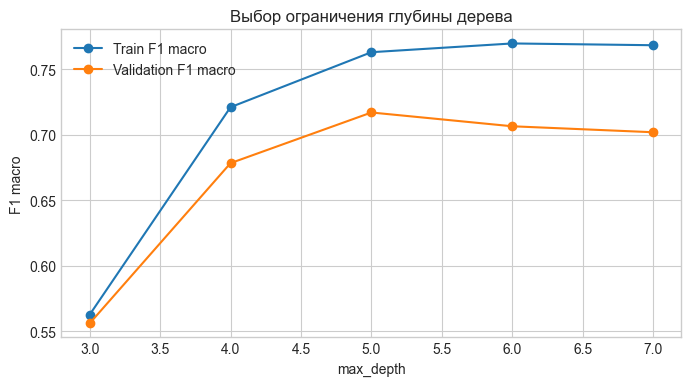

In [11]:
best_row = depth_results.sort_values(['val_f1_macro', 'max_depth'], ascending=[False, True]).iloc[0]
BEST_MAX_DEPTH = int(best_row['max_depth'])
print(f"Выбранное ограничение глубины: max_depth = {BEST_MAX_DEPTH}")
print(f"Validation F1 macro = {best_row['val_f1_macro']:.3f}, accuracy = {best_row['val_accuracy']:.3f}")

plt.figure(figsize=(8, 4))
plt.plot(depth_results['max_depth'], depth_results['train_f1_macro'], marker='o', label='Train F1 macro')
plt.plot(depth_results['max_depth'], depth_results['val_f1_macro'], marker='o', label='Validation F1 macro')
plt.xlabel('max_depth')
plt.ylabel('F1 macro')
plt.title('Выбор ограничения глубины дерева')
plt.legend()
plt.show()

## Обучение Random Forest

Финальная модель обучается на bootstrap выборках. Каждое дерево получает случайное подмножество объектов и на каждом узле случайное подмножество признаков (`max_features='sqrt'`)

In [12]:
forest = RandomForest(
    n_estimators=25,
    max_depth=BEST_MAX_DEPTH,
    min_samples_leaf=8,
    min_samples_split=24,
    max_features='sqrt',
    max_thresholds=16,
    min_branches=3,
    max_branches=4,
    threshold_trials=8,
    random_state=RANDOM_STATE,
)
forest.fit(X_train, y_train)

train_pred = forest.predict(X_train)
val_pred = forest.predict(X_val)
val_proba = forest.predict_proba(X_val)

train_metrics = classification_metrics(y_train, train_pred, labels=np.arange(len(class_names)))
val_metrics = classification_metrics(y_val, val_pred, labels=np.arange(len(class_names)))

pd.DataFrame([
    {'part': 'train', **{key: value for key, value in train_metrics.items() if key != 'per_class'}},
    {'part': 'validation', **{key: value for key, value in val_metrics.items() if key != 'per_class'}},
])

,part,accuracy,precision_macro,recall_macro,f1_macro
0,train,0.872375,0.784714,0.763501,0.771410
1,validation,0.832021,0.755783,0.718414,0.730121


In [13]:
per_class = val_metrics['per_class'].copy()
per_class['class_name'] = per_class['label'].map(id_to_class)
per_class[['class_name', 'precision', 'recall', 'f1', 'support']]

,class_name,precision,recall,f1,support
0,carpet,0.916667,0.578947,0.709677,38
1,concrete,0.846626,0.884615,0.865204,156
2,fine_concrete,0.836364,0.630137,0.718750,73
3,hard_tiles,0.000000,0.000000,0.000000,4
4,hard_tiles_large_space,0.963636,0.854839,0.905983,62
5,soft_pvc,0.822086,0.917808,0.867314,146
6,soft_tiles,0.833333,0.932203,0.880000,59
7,tiled,0.833333,0.873786,0.853081,103
8,wood,0.750000,0.793388,0.771084,121


## ROC-кривая

Задача многоклассовая, поэтому ROC строится по схеме one-vs-rest: для каждого класса он считается как положительный класс против всех остальных

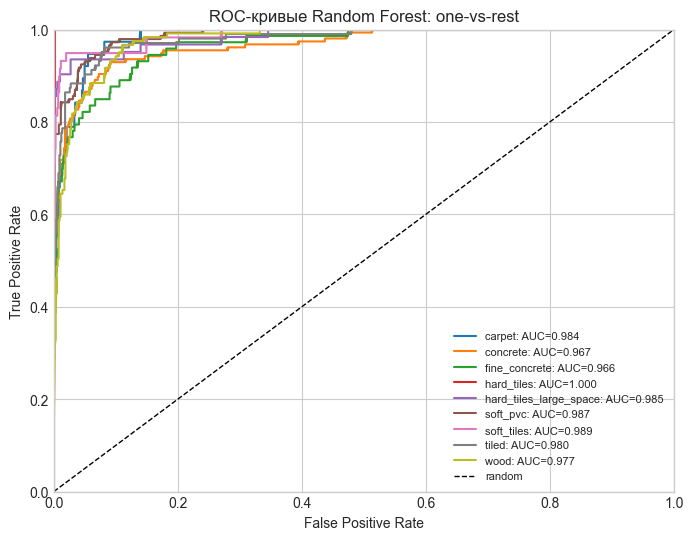

Macro ROC-AUC = 0.982


,class_name,auc
0,carpet,0.983952
1,concrete,0.967118
2,fine_concrete,0.966330
3,hard_tiles,0.999670
4,hard_tiles_large_space,0.984597
5,soft_pvc,0.987441
6,soft_tiles,0.988512
7,tiled,0.980376
8,wood,0.976696


In [ ]:
def binary_roc_curve(y_true_binary, y_scores):
    """ROC для одного класса против остальных"""
    y_true_binary = np.asarray(y_true_binary, dtype=int)
    y_scores = np.asarray(y_scores, dtype=float)

    idx_sorted = np.argsort(y_scores)[::-1]
    y_true_binary = y_true_binary[idx_sorted]
    y_scores = y_scores[idx_sorted]

    tprs = []
    fprs = []
    n = len(y_scores)

    for i in range(n + 1):
        if i == 0:
            threshold = np.inf
        elif i == n:
            threshold = -np.inf
        else:
            threshold = (y_scores[i - 1] + y_scores[i]) / 2.0

        y_pred = np.where(y_scores <= threshold, -1, 1)
        tp = np.sum((y_pred == 1) & (y_true_binary == 1))
        tn = np.sum((y_pred == -1) & (y_true_binary == -1))
        fn = np.sum((y_pred == -1) & (y_true_binary == 1))
        fp = np.sum((y_pred == 1) & (y_true_binary == -1))

        tpr = tp / (tp + fn + 1e-12)
        fpr = fp / (fp + tn + 1e-12)
        tprs.append(tpr)
        fprs.append(fpr)

    order = np.argsort(fprs)
    fpr_sorted = np.array(fprs)[order]
    tpr_sorted = np.array(tprs)[order]
    auc = float(np.trapezoid(tpr_sorted, fpr_sorted))
    return fpr_sorted, tpr_sorted, auc


def plot_multiclass_roc(y_true, proba, class_names):
    aucs = []
    plt.figure(figsize=(8, 6))

    for class_id, class_name in enumerate(class_names):
        y_binary = np.where(y_true == class_id, 1, -1)
        fpr, tpr, auc = binary_roc_curve(y_binary, proba[:, class_id])
        aucs.append(auc)
        plt.plot(fpr, tpr, linewidth=1.5, label=f'{class_name}: AUC={auc:.3f}')

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='random')
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.0)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-кривые Random Forest: one-vs-rest')
    plt.legend(fontsize=8)
    plt.show()

    return float(np.mean(aucs)), pd.DataFrame({'class_name': class_names, 'auc': aucs})


macro_auc, roc_table = plot_multiclass_roc(y_val, val_proba, class_names)
print(f'Macro ROC-AUC = {macro_auc:.3f}')
roc_table